# Mean-Squared Displacement (MSD) Analysis

This notebook analyzes the translational motion of the **mobile particle population** (`type == 2`) from OVITO/LAMMPS trajectory files.

Two related MSD definitions are implemented:

- **Initial-reference MSD (`VelValOvito`)** — each particle is compared with its own position in the first recorded frame.
- **Time-lag MSD (`VelValTimeLagMsdOvito`)** — positions separated by a given lag are compared using all valid time origins and all mobile particles.

The overall data flow is:

**LAMMPS trajectory → OVITO unwrapping → particle-level pandas table → mobile-particle selection → ordered particle trajectories → squared displacement → ensemble averaging → MSD comparison / characteristic displacement estimates**

Trajectory unwrapping is important because a particle crossing a periodic boundary should remain part of a continuous physical trajectory rather than appearing to make an artificial large coordinate jump.


In [5]:
# Libraries used for tabular particle data, numerical calculations,
# plotting, OVITO trajectory import, and periodic-boundary unwrapping.
#
# The trajectory data handled later in this notebook consist of particle IDs,
# particle types, simulation timesteps, and three-dimensional coordinates.

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
from ovito.io import import_file
from ovito.modifiers import UnwrapTrajectoriesModifier

## 1. Core trajectory-to-MSD functions

Each OVITO frame is converted to a pandas DataFrame with the columns:

`frame`, `id`, `type`, `x`, `y`, `z`

Each row therefore represents **one particle observed at one stored simulation time**.

Only `type == 2` particles are retained for the MSD analysis, corresponding to the mobile population. Sorting by `id` and `frame` reconstructs the chronological trajectory of every individual mobile particle.

### `VelValOvito`: displacement from the initial position

For each particle, its first recorded coordinates are stored as `x0` and `y0`. The notebook then calculates

\[
\mathrm{MSD}(t)
=
\left\langle [x(t)-x(0)]^2 + [y(t)-y(0)]^2 \right\rangle ,
\]

where the average is taken over mobile particles at each frame.

### `VelValTimeLagMsdOvito`: time-lag MSD

This version does not use only the first frame as a reference. For every available lag, it calculates coordinate differences between all pairs of observations separated by that lag. Squared displacements are accumulated across particles and all valid time origins before being divided by the number of contributing samples.

### `msdO` and `msdOLag`: ensemble aggregation

`msdO` combines initial-reference MSD curves from multiple realizations.

`msdOLag` processes ten `Ne` structures with five repeated realizations each, skips trajectories that cannot be read, averages the repeated runs within each `Ne`, and then averages across the `Ne` structures.


In [ ]:
# ---------------------------------------------------------------------------
# MSD PROCESSING FUNCTIONS
# ---------------------------------------------------------------------------
#
# VelValOvito(dir)
#   Reads one LAMMPS trajectory with OVITO, unwraps periodic trajectories,
#   converts every frame to particle-level pandas data, selects mobile
#   particles (type 2), sorts observations by particle ID and frame, and
#   computes squared displacement relative to each particle's first position.
#
# VelValTimeLagMsdOvito(dir)
#   Builds the same cleaned mobile-particle trajectory table but calculates
#   displacement for every available time lag. For a given lag, vector slices
#   compare all valid position pairs separated by that lag. msdSum stores the
#   accumulated squared displacement and counter stores the number of samples
#   contributing to each lag.
#
# msdO(Ang, shape)
#   Collects initial-reference MSD curves for multiple realizations of a
#   selected structure and driving angle, aligns them by index, and takes the
#   ensemble mean.
#
# msdOLag(Ang, shape)
#   Performs the time-lag calculation for Ne = 1..10 and R = 1..5, averages
#   repeated realizations within each Ne, and then averages across Ne values.
#
# Important data types:
#   frame        -> Python list of per-frame pandas DataFrames
#   Trj2         -> long-form pandas DataFrame containing all particle frames
#   CleanData    -> DataFrame restricted to type-2/mobile particles
#   NewClean     -> same particle data ordered by ID and simulation frame
#   x, y         -> NumPy coordinate arrays for one particle trajectory
#   msdSum       -> NumPy float array accumulating squared displacement by lag
#   counter      -> NumPy float array counting valid samples by lag
#   FinalMsd     -> pandas DataFrame with realization-specific MSD curves
#   MeanMsd      -> pandas Series containing their ensemble mean
#
def VelValOvito(dir):
    pd.set_option("display.max_rows", None)

    pipe = import_file(dir)
    pipe.modifiers.append(
    UnwrapTrajectoriesModifier()
    )
    frame = []
    for i in range(pipe.source.num_frames):
        data = pipe.compute(i)

        dataframe = pd.DataFrame({"frame": np.full(data.particles.count,data.attributes['Timestep'])})
        dataframe["id"] = data.particles['Particle Identifier']
        dataframe["type"] = data.particles['Particle Type']
        dataframe["x"] = data.particles.positions[:,0]
        dataframe["y"] = data.particles.positions[:,1]
        dataframe["z"] = data.particles.positions[:,2]

        frame.append(dataframe)

    Trj2= pd.concat(frame, ignore_index= True)
    Trj2.columns = Trj2.columns.str.strip()

    Trj2 = Trj2.copy()
 
    CleanData = Trj2[Trj2["type"] == 2].copy()
    NewClean = CleanData.sort_values(["id","frame"])

    NewClean["x0"] = NewClean.groupby("id")["x"].transform("first")
    NewClean["y0"] = NewClean.groupby("id")["y"].transform("first")

    NewClean["dx2"] = (NewClean["x"] - NewClean["x0"])**2
    NewClean["dy2"] = (NewClean["y"] - NewClean["y0"])**2

    meanmsd = NewClean.groupby("frame")[["dx2", "dy2"]].mean()    
    meanmsd["msd"] = meanmsd["dx2"] + meanmsd["dy2"]

    return meanmsd

def VelValTimeLagMsdOvito(dir):
    pd.set_option("display.max_rows", None)

    pipe = import_file(dir)
    pipe.modifiers.append(
    UnwrapTrajectoriesModifier()
    )
    frame = []
    for i in range(pipe.source.num_frames):
        data = pipe.compute(i)

        dataframe = pd.DataFrame({"frame": np.full(data.particles.count,data.attributes['Timestep'])})
        dataframe["id"] = data.particles['Particle Identifier']
        dataframe["type"] = data.particles['Particle Type']
        dataframe["x"] = data.particles.positions[:,0]
        dataframe["y"] = data.particles.positions[:,1]
        dataframe["z"] = data.particles.positions[:,2]

        frame.append(dataframe)

    Trj2= pd.concat(frame, ignore_index= True)
    Trj2.columns = Trj2.columns.str.strip()

    Trj2 = Trj2.copy()
 
    CleanData = Trj2[Trj2["type"] == 2].copy()
    NewClean = CleanData.sort_values(["id","frame"])
    
    lagsies = NewClean.groupby("id").size().max()

    msdSum = np.zeros(lagsies, dtype =np.float64)
    counter = np.zeros(lagsies, dtype =np.float64)
    for nothing,g in NewClean.groupby("id"):
        x = g["x"].to_numpy()
        y = g["y"].to_numpy()
        T = len(x)
        
        for lag in range(1,T):
            dx = x[lag:] - x[:-lag]
            dy = y[lag:] - y[:-lag]
            msdvls = dx*dx + dy*dy
            msdSum[lag] += msdvls.sum()
            counter[lag] += msdvls.size

    mean = msdSum[1:]/ counter[1:]
    return pd.DataFrame({"msd": mean}, index = np.arange(1, lagsies))

def msdO(Ang,shape):
    
    MsdMR =[]
    for jj,j in enumerate(list):
       
        msd = VelValOvito(f"C:/Users/olind/Documents/QuasiCrystalTono/ParquetFiles/{shape}/MultiParticle{shape}_{j}_{Ang}.lammpstrj.gz")
        totalMsd = msd["msd"]
        t = totalMsd[totalMsd.index > 0]
        
        totalMsd.name = f"R{j+1}"
        MsdMR.append(totalMsd)

    FinalMsd = pd.concat(MsdMR, axis =1)
    MeanMsd =  FinalMsd.mean(axis =1, skipna = True)
    t = MeanMsd.index.to_numpy()
    return MeanMsd.to_numpy(), t

def msdOLag(Ang,shape):
    MsdMrAll = []
    for i in range (1,11):
        MsdMR =[]
        for j in range (1,6):
            try:
                msd = VelValTimeLagMsdOvito(f"D:/{shape}V2FR50/MPV2{shape}_Ne{i}_P25_R{j}_{Ang}_FR50.lammpstrj.gz")
            except Exception as e:
                print(f"D:/{shape}V2FR50/MPV2{shape}_Ne{i}_P25_R{j}_{Ang}_FR50.lammpstrj.gz")
                continue
            totalMsd = msd["msd"]
            t = totalMsd[totalMsd.index > 0]
            
            totalMsd.name = f"Ne{i}_R{j}_FR50"
            MsdMR.append(totalMsd)

        FinalMsd = pd.concat(MsdMR, axis =1)
        MeanMsd =  FinalMsd.mean(axis =1, skipna = True)
        MsdMrAll.append(MeanMsd)
    TotalFinalMsd = pd.concat(MsdMrAll, axis =1)
    TotalMeanMsd =  TotalFinalMsd.mean(axis =1, skipna = True)
    t = TotalFinalMsd.index.to_numpy()

    return TotalMeanMsd.to_numpy(), t



## 2. Calculate one selected MSD condition

The next cell evaluates the initial-reference MSD at driving angle `100` for structure `N7`.

`M7` contains the resulting ensemble-averaged MSD values and `t7` contains the corresponding trajectory index/timestep values.


In [2]:
# Evaluate the selected structure/angle condition.

M7, t7 = msdO(100,"N7")



TypeError: msdO() missing 1 required positional argument: 'shape'

## 3. Optional export of processed MSD data

These save commands are disabled in the original notebook. When enabled, they cache the processed MSD and corresponding time/frame arrays as CSV files so later plotting does not require reprocessing the full trajectories.


In [ ]:
# Optional CSV export; currently disabled.

#np.savetxt("D:/N7V2FR50Analysis/MSDN7Angle100P25.csv", M7, delimiter=",", fmt='%d')
#np.savetxt("D:/N7V2FR50Analysis/t7N7Angle100P25.csv", t7, delimiter=",", fmt='%d')

## 4. Load previously processed comparison datasets

The notebook loads two previously calculated MSD datasets together with their corresponding time axes.

The later plot labels these conditions as **1:1** (`P1`) and **1:4** (`P25`).


In [7]:
# Load the stored MSD curves and their associated normalized-frame/time arrays.
mds25 = pd.read_csv("D:/N7V2FR50Analysis/MSDN7Angle100P25.csv")
msd1 = pd.read_csv("D:/N7V2FR50Analysis/MSDN7Angle100P1.csv")
t1 = pd.read_csv("D:/N7V2FR50Analysis/t7N7Angle100P1.csv")
t25 = pd.read_csv("D:/N7V2FR50Analysis/t7N7Angle100P25.csv")


## 5. Compare the two MSD curves

Both datasets are plotted on logarithmic x and y axes. A log-log representation is useful for comparing changes across multiple temporal and displacement scales.


Text(0, 0.5, 'MSD')

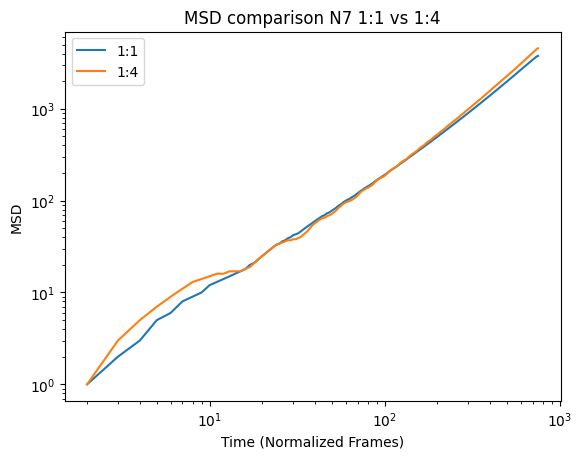

In [8]:
# Plot both particle-ratio conditions on log-log axes for direct comparison.


plt.loglog(t1, msd1, label = "1:1")
plt.loglog(t25, mds25, label = "1:4")
plt.title("MSD comparison N7 1:1 vs 1:4")
plt.legend()
plt.xlabel("Time (Normalized Frames)")
plt.ylabel("MSD")

## 6. Inspect a selected region of the `P25` MSD curve

The complete curve is shown together with the subset at positional DataFrame indices 12 through 29.

`msddiff` then calculates the absolute difference between the MSD values at positional indices 30 and 12. Because `.iloc` is used, these are **row positions**, not values selected by a specified physical time.


0    22
dtype: int64


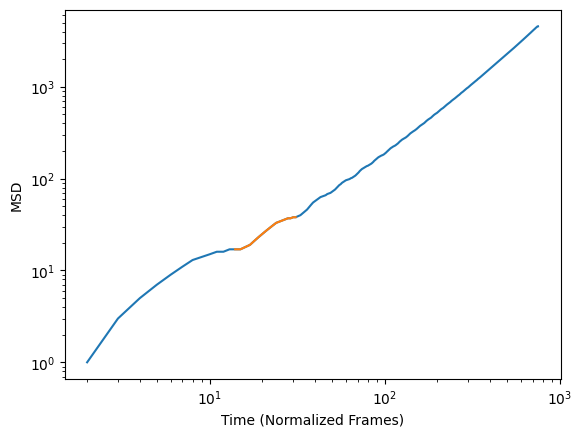

In [39]:
# Inspect a selected MSD interval and calculate its absolute MSD change.
plt.loglog(t25, mds25)
#plt.xlim(10**0.9,10**2)
#plt.ylim(10**1,6*10**1)
plt.loglog(t25.iloc[12:30], mds25.iloc[12:30])
plt.xlabel("Time (Normalized Frames)")
plt.ylabel("MSD")
msddiff = mds25.iloc[30] - mds25.iloc[12]
print(msddiff)

## 7. Difference in logarithmic MSD

The same two selected MSD values are compared in base-10 logarithmic space:

\[
\Delta \log_{10}(\mathrm{MSD})
=
\log_{10}(\mathrm{MSD}_{30})
-
\log_{10}(\mathrm{MSD}_{12}).
\]

This expresses their separation in the same logarithmic representation used by the MSD plot.


In [35]:
# Calculate the separation of the selected MSD values in log10 space.
logdiff = np.log10(mds25.iloc[30]) - np.log10(mds25.iloc[12])
print(logdiff)

0    0.360616
dtype: float64


## 8. Relative MSD and characteristic displacement scale

Because MSD has dimensions of length squared, taking its square root produces a characteristic displacement scale.

The notebook first calculates the MSD ratio and then takes its square root, producing the corresponding ratio between characteristic displacement magnitudes.


In [37]:
# Convert the MSD ratio to a characteristic displacement-length ratio.
ratio = mds25.iloc[30] / mds25.iloc[12]
length_scale = np.sqrt(ratio)
print(length_scale)

0    1.514634
dtype: float64


## 9. Difference between characteristic displacement scales

The final quantity stored as `osc_length` is

\[
\sqrt{\mathrm{MSD}_{30}}-\sqrt{\mathrm{MSD}_{12}}.
\]

It measures the difference between the square-root-MSD displacement scales associated with the two selected points.


In [40]:
# Calculate the difference between the two square-root MSD scales.
osc_length = np.sqrt(mds25.iloc[30]) - np.sqrt(mds25.iloc[12])
print(osc_length)

0    2.121892
dtype: float64
